# Available Optical and Radio Stations in Tudat

## Objectives
With this short example, you will see how easy it is, within Tudatpy, to load pre-existing optical and radio stations coordinates. The mapping of cartesian coordinates to the telescope codes and names can be found in two files, named [`glo.sit`](https://gitlab.com/gofrito/pysctrack/-/blob/master/cats/glo.sit?ref_type=heads) and [`mpc.sit`](https://www.projectpluto.com/mpc_stat.txt) (click on their names to be redirected to the links where they are hosted). These come packaged with Tudatpy. 

## Import Statements
Here, we load the needed Tudatpy dependencies, such as `environment_setup` to load the stations, and `element_conversion`, used to convert cartesian positions into geodetic coordinates. Moreover, we will use the `cartopy` dependency to show nice maps to get an idea on where exactly the ground stations are located in the world. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tudatpy.dynamics import environment_setup
from tudatpy.astro import element_conversion

## Helper Function
We define an helper function that takes the station settings list as input, and returns arrays of geodetic latitudes and longitudes, and the corresponding station codes. We need such a function, because the original files (`glo.sit`, `mpc.sit`) store coordinates in cartesian elements, yet we want to plot geodetic coordinates. We will use the [WGS84](https://share.google/d2p2b46f8FWXm3DJc) values to define Earth's flattening and equatorial radius. 

In [2]:
def get_station_geodetic_coordinates(station_settings_list):
    """
    Extract geodetic coordinates (lon, lat) from Tudat ground stations.
    """
    equatorial_radius = 6378.137e3  # WGS84
    flattening = 1.0 / 298.257223563 # WGS84

    lons, lats, codes = [], [], []

    for station in station_settings_list:
        cartesian_pos = station.station_position
        geodetic_pos = element_conversion.convert_cartesian_to_geodetic_coordinates(
            cartesian_coordinates=cartesian_pos,
            equatorial_radius=equatorial_radius,
            flattening=flattening,
            tolerance=1.0e-4
        )

        lats.append(np.rad2deg(geodetic_pos[1]))
        lons.append(np.rad2deg(geodetic_pos[2]))
        codes.append(station.station_name)

    return np.array(lons), np.array(lats), np.array(codes)

## Load ground station settings

The next snippet shows how easy it is to load both radio and optical telescope settings within Tudatpy. You just need two lines to unlock a huge number of stations, whose coordinates are ready to be used within a tudat observation simulation or estimation script. 

In [3]:
radio_stations_settings = environment_setup.ground_station.radio_telescope_stations()
optical_stations_settings = environment_setup.ground_station.optical_telescope_stations()


## Explore Available Ground Stations

We are now finally ready to give both radio and optcial stations settings to the helper function we defined above. We can also take a look at the vlbi denominations and mpc codes by printing their names. 

In [4]:
radio_lons, radio_lats, radio_names = get_station_geodetic_coordinates(radio_stations_settings)
optical_lons, optical_lats, optical_names = get_station_geodetic_coordinates(optical_stations_settings)

print("Slice of Radio Codes:", radio_names[20:30])
print("Slice of Optical Codes:", optical_names[20:30])

Slice of Radio Codes: ['DSS-65' 'AIRA' 'ALGOPARK' 'ARECIBO' 'ASKAP-29' 'ATCA-104' 'ATCAPN5'
 'AUSTINTX' 'AZORES' 'BADARY']
Slice of Optical Codes: ['020' '021' '022' '023' '024' '025' '026' '027' '028' '029']


## Plot Ground Stations
Last but not least, we can plot the geodetic coordinates of all our Tudat-available ground stations. As an example, we plot `DWINGELOO` and the `VERA RUBIN OBSERVATORY` with different colors and shapes, to make them stand out. Play around with this code to make your favourite ground stations stand out!

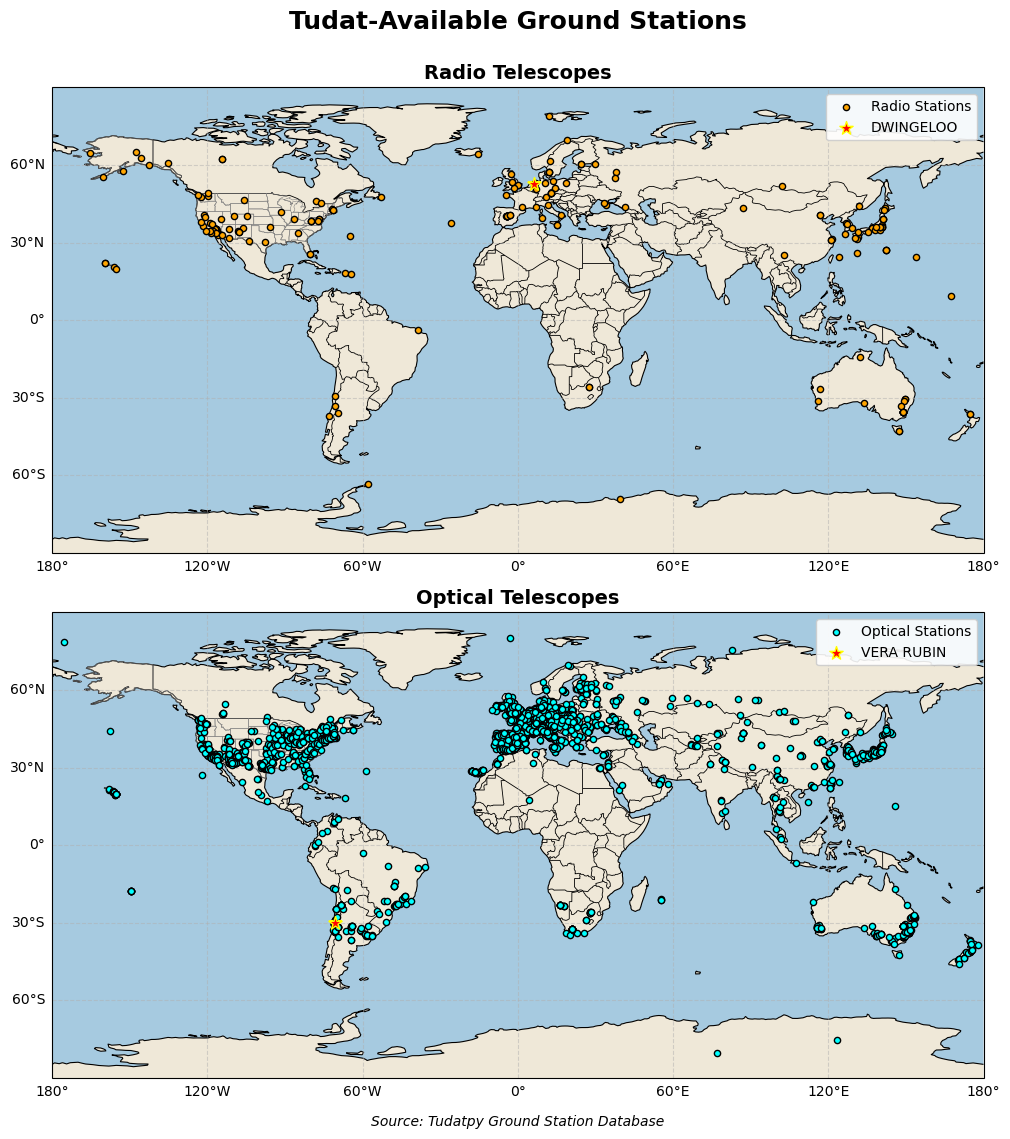

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(15, 12), subplot_kw={'projection': ccrs.PlateCarree()})
titles = ["Radio Telescopes", "Optical Telescopes"]
data = [(radio_lons, radio_lats, 'orange', 'o', 'Radio'), 
        (optical_lons, optical_lats, 'cyan', 'o', 'Optical')]
for i, ax in enumerate(axes):
    # Background
    ax.add_feature(cfeature.OCEAN, facecolor='#A6CAE0', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='#EFE8D8', zorder=0)

    # Geographic features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, zorder=1)
    ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor='gray', zorder=1)

    lons, lats, color, marker, label = data[i]

    ax.scatter(
        lons, lats,
        c=color, edgecolors='black', s=20, marker=marker,
        label=f'{label} Stations', linewidth=1, zorder=3,
        transform=ccrs.PlateCarree()
    )

    if label == "Radio":
        dwingeloo_index = np.where(np.array(radio_names) == "DWINGELO")[0]
        ax.scatter(
            lons[dwingeloo_index], lats[dwingeloo_index],
            c="red", edgecolors='yellow', s=100, marker="*",
            label=f'DWINGELOO', linewidth=1, zorder=3,
            transform=ccrs.PlateCarree()
        )
    elif label == "Optical":
        vera_rubin_index = np.where(np.array(optical_names) == "X05")[0]
        ax.scatter(
            lons[vera_rubin_index], lats[vera_rubin_index],
            c="red", edgecolors='yellow', s=100, marker="*",
            label=f'VERA RUBIN', linewidth=1, zorder=3,
            transform=ccrs.PlateCarree()
        ) 
    
    ax.set_title(titles[i], fontsize=14, fontweight='bold')
    ax.set_global()
    ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
fig.suptitle("Tudat-Available Ground Stations", fontsize=18, fontweight='bold', y=0.95)
plt.figtext(
    0.5, 0.02,
    "Source: Tudatpy Ground Station Database",
    ha='center',
    fontsize=10,
    style='italic'
)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()